<a href="https://colab.research.google.com/github/mikeethanh/.NET-Core/blob/master/heart_disease_cleveland.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
ritwikb3_heart_disease_cleveland_path = kagglehub.dataset_download('ritwikb3/heart-disease-cleveland')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-cleveland/Heart_disease_cleveland_new.csv


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ritwikb3/heart-disease-cleveland")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/heart-disease-cleveland


In [ ]:
# header = None tức là mình không thêm header vào và mình tự thêm header
df = pd.read_csv("/kaggle/input/heart-disease-cleveland/Heart_disease_cleveland_new.csv",header = None)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
2,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
3,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
4,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,45,1,0,110,264,0,0,132,0,1.2,1,0,3,1
300,68,1,3,144,193,1,0,141,0,3.4,1,2,3,1
301,57,1,3,130,131,0,0,115,1,1.2,1,1,3,1
302,57,0,1,130,236,0,2,174,0,0,1,1,1,1


In [ ]:
df.shape


(304, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       304 non-null    object
 1   1       304 non-null    object
 2   2       304 non-null    object
 3   3       304 non-null    object
 4   4       304 non-null    object
 5   5       304 non-null    object
 6   6       304 non-null    object
 7   7       304 non-null    object
 8   8       304 non-null    object
 9   9       304 non-null    object
 10  10      304 non-null    object
 11  11      304 non-null    object
 12  12      304 non-null    object
 13  13      304 non-null    object
dtypes: object(14)
memory usage: 33.4+ KB


In [ ]:
df.isnull().sum

<bound method DataFrame.sum of         0      1      2      3      4      5      6      7      8      9   \
0    False  False  False  False  False  False  False  False  False  False   
1    False  False  False  False  False  False  False  False  False  False   
2    False  False  False  False  False  False  False  False  False  False   
3    False  False  False  False  False  False  False  False  False  False   
4    False  False  False  False  False  False  False  False  False  False   
..     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
299  False  False  False  False  False  False  False  False  False  False   
300  False  False  False  False  False  False  False  False  False  False   
301  False  False  False  False  False  False  False  False  False  False   
302  False  False  False  False  False  False  False  False  False  False   
303  False  False  False  False  False  False  False  False  False  False   

        10     11     12     13  
0    False

In [ ]:
df.isna().sum()


0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64

In [ ]:
df.describe()  # Thống kê tổng quan (chỉ với cột số)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,304,304,304,304,304,304,304,304,304,304,304,304,304,304
unique,42,3,5,51,153,3,4,92,3,41,4,5,4,3
top,58,1,3,120,197,0,0,162,0,0,0,0,1,0
freq,19,206,144,37,6,258,151,11,204,99,142,180,168,164


In [ ]:
df.duplicated().sum()  # Số lượng dòng bị trùng

0

In [ ]:
# nhan xet : Du lieu nay da duoc clean , khong co gia tri null , na

In [ ]:
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
2,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
3,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
4,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,45,1,0,110,264,0,0,132,0,1.2,1,0,3,1
300,68,1,3,144,193,1,0,141,0,3.4,1,2,3,1
301,57,1,3,130,131,0,0,115,1,1.2,1,1,3,1
302,57,0,1,130,236,0,2,174,0,0,1,1,1,1


In [ ]:
df['thalach'].unique()


array(['thalach', '150', '108', '129', '187', '172', '178', '160', '163',
       '147', '155', '148', '153', '142', '173', '162', '174', '168',
       '139', '171', '144', '132', '158', '114', '151', '161', '179',
       '120', '112', '137', '157', '169', '165', '123', '128', '152',
       '140', '188', '109', '125', '131', '170', '113', '99', '177',
       '141', '180', '111', '143', '182', '156', '115', '149', '145',
       '146', '175', '186', '185', '159', '130', '190', '136', '97',
       '127', '154', '133', '126', '202', '103', '166', '164', '184',
       '124', '122', '96', '138', '88', '105', '194', '195', '106', '167',
       '95', '192', '117', '121', '116', '71', '118', '181', '134', '90'],
      dtype=object)

In [ ]:
df['thalach'] = pd.to_numeric(df['thalach'], errors='coerce')


In [ ]:
# filling missing data su dung mean va dat ten cho côt
df.columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldspeak','slope','ca','thal','target']
df


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldspeak,slope,ca,thal,target
0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
2,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
3,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
4,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,45,1,0,110,264,0,0,132,0,1.2,1,0,3,1
300,68,1,3,144,193,1,0,141,0,3.4,1,2,3,1
301,57,1,3,130,131,0,0,115,1,1.2,1,1,3,1
302,57,0,1,130,236,0,2,174,0,0,1,1,1,1


In [ ]:
df['thalach'] = df['thalach'].fillna(df['thalach'].mean())
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldspeak,slope,ca,thal,target
0,age,sex,cp,trestbps,chol,fbs,restecg,149.607261,exang,oldpeak,slope,ca,thal,target
1,63,1,0,145,233,1,2,150.000000,0,2.3,2,0,2,0
2,67,1,3,160,286,0,2,108.000000,1,1.5,1,3,1,1
3,67,1,3,120,229,0,2,129.000000,1,2.6,1,2,3,1
4,37,1,2,130,250,0,0,187.000000,0,3.5,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,45,1,0,110,264,0,0,132.000000,0,1.2,1,0,3,1
300,68,1,3,144,193,1,0,141.000000,0,3.4,1,2,3,1
301,57,1,3,130,131,0,0,115.000000,1,1.2,1,1,3,1
302,57,0,1,130,236,0,2,174.000000,0,0,1,1,1,1


In [ ]:
#loai bo hang dau tien
df = df.iloc[1:].reset_index(drop=True)

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldspeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,0,110,264,0,0,132,0,1.2,1,0,3,1
299,68,1,3,144,193,1,0,141,0,3.4,1,2,3,1
300,57,1,3,130,131,0,0,115,1,1.2,1,1,3,1
301,57,0,1,130,236,0,2,174,0,0,1,1,1,1


In [ ]:
import seaborn as sns


In [ ]:
import matplotlib.pyplot as plt

<Figure size 1200x600 with 0 Axes>

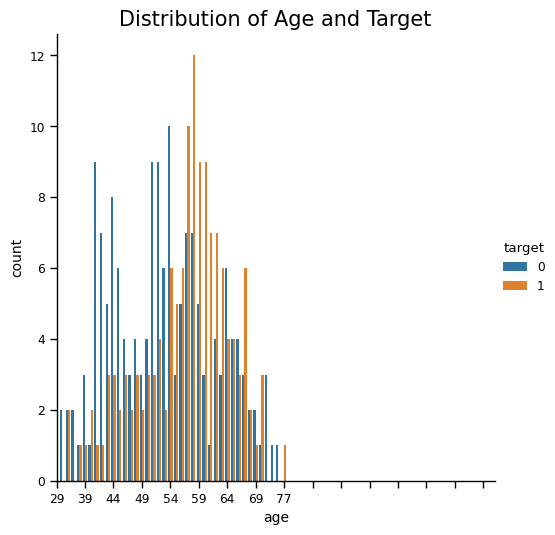

In [ ]:
#distribution of target and age
sns.set_context("paper", font_scale=1, rc={"font.size": 3, "axes.titlesize": 15, "axes.labelsize": 10})
plt.figure(figsize=(12, 6))
# Sắp xếp theo giá trị duy nhất của 'age'
sorted_ages = sorted(df['age'].unique())

ax = sns.catplot(kind="count", data=df, x="age", hue="target", order=sorted_ages)

ax.ax.set_xticks(np.arange(0, 80, 5))
# Giới hạn trục X để không bị dư thừa
ax.set(xlim=(0, 77))

plt.title("Distribution of Age and Target")
plt.show()

Phân phối gần giống gaussian distribution

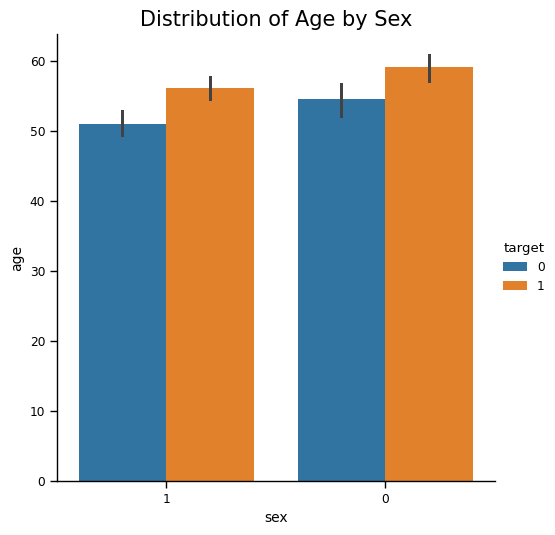

In [ ]:
#phải đổi sang kiểu numeric mới vẽ đc biểu đồ barplot
df['age'] = pd.to_numeric(df['age'], errors='coerce')
sns.catplot(data=df,x='sex', y='age', kind='bar',hue = 'target')

# Thêm tiêu đề
plt.title("Distribution of Age by Sex")
plt.show()

In [ ]:
#KNN
#lấy tất cả các hàng và cột trừ cột cuối
X = df.iloc[:,:-1].values
#lấy tất cả các hàng ở cột cuối
y = df.iloc[:,-1].values
#: random_state:Phân chia dữ liệu sẽ luôn giống nhau mỗi lần chạy lại code, giúp bạn tái tạo lại kết quả khi cần thiết.
from sklearn.model_selection import train_test_split
X_train , X_test, y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

print(f"Số lượng mẫu trong tập huấn luyện: {X_train.shape[0]}")
print(f"Số lượng mẫu trong tập kiểm tra: {X_test.shape[0]}")

Số lượng mẫu trong tập huấn luyện: 242
Số lượng mẫu trong tập kiểm tra: 61


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# Tạo mô hình KNN
classifier = KNeighborsClassifier(n_neighbors=9, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski')

# Huấn luyện mô hình
classifier.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
# Tính ma trận nhầm lẫn cho tập kiểm tra
cm_test = confusion_matrix(y_test, y_pred)

# Dự đoán trên tập huấn luyện
y_pred_train = classifier.predict(X_train)

# Tính ma trận nhầm lẫn cho tập huấn luyện
cm_train = confusion_matrix(y_train, y_pred_train)

# In ma trận nhầm lẫn
print("Confusion Matrix for Train Set:")
print(cm_train)

print("Confusion Matrix for Test Set:")
print(cm_test)

# Tính độ chính xác trên tập huấn luyện
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)

# Tính độ chính xác trên tập kiểm tra
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)

# In kết quả độ chính xác
print(f"Accuracy for Train Set: {accuracy_for_train}")
print(f"Accuracy for Test Set: {accuracy_for_test}")

Confusion Matrix for Train Set:
[[108  27]
 [ 45  62]]
Confusion Matrix for Test Set:
[[22  7]
 [10 22]]
Accuracy for Train Set: 0.7
Accuracy for Test Set: 0.72


Trong thuật toán K-Nearest Neighbors (KNN), tham số leaf_size kiểm soát kích thước của các "lá" trong cây dữ liệu khi sử dụng cấu trúc dữ liệu cây để tăng tốc việc tìm kiếm các điểm gần nhất. Cụ thể, leaf_size ảnh hưởng đến hiệu quả của việc tìm kiếm khi cây KD-tree hoặc Ball-tree được sử dụng.

Cây KD-tree là một cấu trúc dữ liệu dùng để chia không gian thành các vùng, mỗi vùng chứa một nhóm điểm gần nhau, giúp việc tìm kiếm nhanh hơn.

leaf_size = 30 có nghĩa là mỗi lá của cây sẽ chứa tối đa 30 điểm. Tham số này có thể điều chỉnh để tìm ra một giá trị tối ưu cho tốc độ và độ chính xác của thuật toán.

In [ ]:
from sklearn.metrics import f1_score

# Danh sách để lưu F1 Score cho mỗi giá trị k
f1_scores = []

# Thử các giá trị k từ 1 đến 20
for k in range(1, 21):
    classifier = KNeighborsClassifier(n_neighbors=k, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski')
    classifier.fit(X_train, y_train)

    # Dự đoán trên tập kiểm tra
    y_pred = classifier.predict(X_test)

    # Đảm bảo y_test và y_pred là số nguyên (0 và 1)
    y_test_int = y_test.astype(int)
    y_pred_int = y_pred.astype(int)

    # Tính F1 Score
    f1 = f1_score(y_test_int, y_pred_int)

    # Lưu F1 Score và k tương ứng
    f1_scores.append((k, f1))

# In các giá trị k và F1 Score tương ứng
for k, f1 in f1_scores:
    print(f"k = {k}, F1 Score = {f1}")


k = 1, F1 Score = 0.5862068965517242
k = 2, F1 Score = 0.5283018867924528
k = 3, F1 Score = 0.6333333333333334
k = 4, F1 Score = 0.52
k = 5, F1 Score = 0.6551724137931033
k = 6, F1 Score = 0.6153846153846154
k = 7, F1 Score = 0.711864406779661
k = 8, F1 Score = 0.6153846153846154
k = 9, F1 Score = 0.7213114754098361
k = 10, F1 Score = 0.6428571428571429
k = 11, F1 Score = 0.6779661016949152
k = 12, F1 Score = 0.6909090909090908
k = 13, F1 Score = 0.6779661016949152
k = 14, F1 Score = 0.6428571428571429
k = 15, F1 Score = 0.6440677966101694
k = 16, F1 Score = 0.6428571428571429
k = 17, F1 Score = 0.6666666666666666
k = 18, F1 Score = 0.6428571428571429
k = 19, F1 Score = 0.711864406779661
k = 20, F1 Score = 0.6545454545454547


In [ ]:
#Gaussian Naive bayes classifier
from sklearn.naive_bayes import GaussianNB

# Tạo mô hình Gaussian Naive Bayes
classifier = GaussianNB()

# Huấn luyện mô hình
classifier.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = classifier.predict(X_test)

# Tính ma trận nhầm lẫn cho tập kiểm tra
cm_test = confusion_matrix(y_test, y_pred)

# Dự đoán trên tập huấn luyện
y_pred_train = classifier.predict(X_train)

# Tính ma trận nhầm lẫn cho tập huấn luyện
cm_train = confusion_matrix(y_train, y_pred_train)

# In ma trận nhầm lẫn
print("Confusion Matrix for Train Set:")
print(cm_train)

print("Confusion Matrix for Test Set:")
print(cm_test)

# Tính độ chính xác trên tập huấn luyện
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)

# Tính độ chính xác trên tập kiểm tra
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)

# In kết quả độ chính xác
print(f"Accuracy for Train Set: {accuracy_for_train}")
print(f"Accuracy for Test Set: {accuracy_for_test}")


Confusion Matrix for Train Set:
[[122  13]
 [ 24  83]]
Confusion Matrix for Test Set:
[[26  3]
 [ 6 26]]
Accuracy for Train Set: 0.85
Accuracy for Test Set: 0.85


vl tốt hơn cả KNN

Dữ liệu có phân phối chuẩn: Nếu dữ liệu của bạn thực sự có phân phối chuẩn (hoặc gần chuẩn) cho mỗi lớp, GaussianNB có thể hoạt động rất tốt và có độ chính xác cao, vì mô hình này tối ưu hóa cho loại dữ liệu này.

Dữ liệu không có phân phối chuẩn: Nếu dữ liệu không có phân phối chuẩn hoặc có nhiều sự thay đổi về phân phối giữa các lớp, KNN có thể hoạt động tốt hơn vì nó không yêu cầu giả định về phân phối của dữ liệu và dựa vào khoảng cách trực tiếp giữa các điểm dữ liệu.

Confusion Matrix for Train Set:
[[126   9]
 [ 28  79]]
Confusion Matrix for Test Set:
[[26  3]
 [ 5 27]]
Accuracy for Train Set: 0.85
Accuracy for Test Set: 0.87


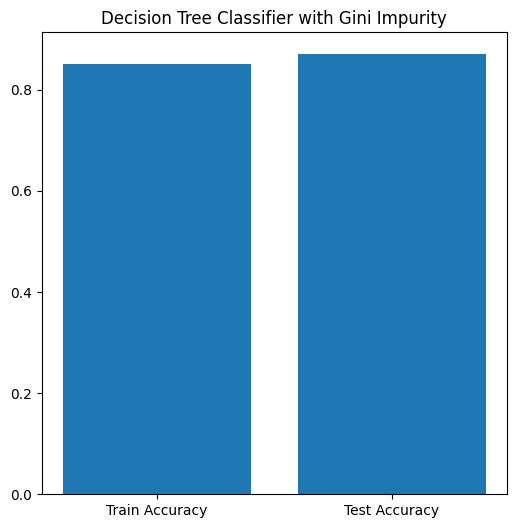

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Tạo mô hình DecisionTree với các tham số được yêu cầu
classifier = DecisionTreeClassifier(
    criterion='gini',          # Sử dụng Gini impurity
    max_depth=10,              # Giới hạn độ sâu tối đa của cây
    min_samples_split=40,       # Số lượng mẫu tối thiểu để chia một nút
    random_state=42            # Đảm bảo tính tái lặp
)

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Tính ma trận nhầm lẫn cho tập kiểm tra
cm_test = confusion_matrix(y_test, y_pred)

# Dự đoán trên tập huấn luyện
y_pred_train = classifier.predict(X_train)

# Tính ma trận nhầm lẫn cho tập huấn luyện
cm_train = confusion_matrix(y_train, y_pred_train)

# In ma trận nhầm lẫn
print("Confusion Matrix for Train Set:")
print(cm_train)

print("Confusion Matrix for Test Set:")
print(cm_test)

# Tính độ chính xác trên tập huấn luyện
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)

# Tính độ chính xác trên tập kiểm tra
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)

# In kết quả độ chính xác
print(f"Accuracy for Train Set: {accuracy_for_train}")
print(f"Accuracy for Test Set: {accuracy_for_test}")

# Vẽ đồ thị nếu cần thiết
plt.figure(figsize=(6,6))
plt.title("Decision Tree Classifier with Gini Impurity")
plt.bar(['Train Accuracy', 'Test Accuracy'], [accuracy_for_train, accuracy_for_test])
plt.show()


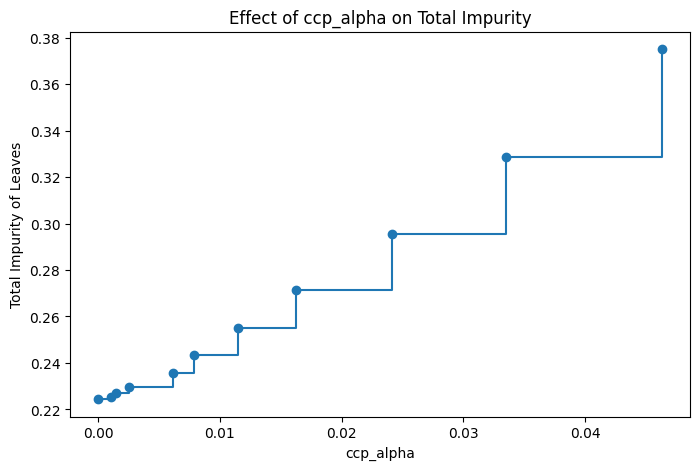

In [ ]:
# Trích xuất giá trị ccp_alpha có thể sử dụng
path = classifier.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Vẽ biểu đồ ccp_alpha và tổng impurity của cây
plt.figure(figsize=(8,5))
plt.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("Total Impurity of Leaves")
plt.title("Effect of ccp_alpha on Total Impurity")
plt.show()

In [ ]:
# Huấn luyện cây với nhiều giá trị alpha khác nhau
trees = []
train_scores = []
test_scores = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    tree.fit(X_train, y_train)

    # Độ chính xác
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

    trees.append(tree)


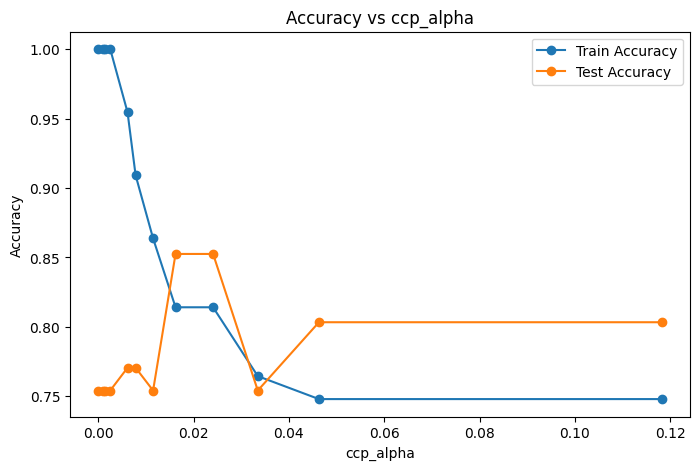

Optimal ccp_alpha: 0.0162


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_scores, marker="o", label="Train Accuracy")
plt.plot(ccp_alphas, test_scores, marker="o", label="Test Accuracy")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy vs ccp_alpha")
plt.show()

# Chọn alpha tối ưu (điểm mà độ chính xác trên tập test cao nhất trước khi giảm)
optimal_alpha = ccp_alphas[np.argmax(test_scores)]
print(f"Optimal ccp_alpha: {optimal_alpha:.4f}")


In [ ]:
classifier_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_alpha)
classifier_pruned.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
# Đánh giá lại
train_acc_pruned = accuracy_score(y_train, classifier_pruned.predict(X_train))
test_acc_pruned = accuracy_score(y_test, classifier_pruned.predict(X_test))

print(f"Accuracy After Pruning - Train: {train_acc_pruned:.2f}, Test: {test_acc_pruned:.2f}")


Accuracy After Pruning - Train: 0.81, Test: 0.85


In [ ]:
classifier = DecisionTreeClassifier(
    criterion='gini',          # Sử dụng Gini impurity
    max_depth=10,              # Giới hạn độ sâu tối đa của cây
    min_samples_split=40,       # Số lượng mẫu tối thiểu để chia một nút
    random_state=42 ,           # Đảm bảo tính tái lặp
    ccp_alpha=0.0162
)

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Tính ma trận nhầm lẫn cho tập kiểm tra
cm_test = confusion_matrix(y_test, y_pred)

# Dự đoán trên tập huấn luyện
y_pred_train = classifier.predict(X_train)

# Tính ma trận nhầm lẫn cho tập huấn luyện
cm_train = confusion_matrix(y_train, y_pred_train)

# In ma trận nhầm lẫn
print("Confusion Matrix for Train Set:")
print(cm_train)

print("Confusion Matrix for Test Set:")
print(cm_test)

# Tính độ chính xác trên tập huấn luyện
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)

# Tính độ chính xác trên tập kiểm tra
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)

# In kết quả độ chính xác
print(f"Accuracy for Train Set: {accuracy_for_train}")
print(f"Accuracy for Test Set: {accuracy_for_test}")


Confusion Matrix for Train Set:
[[124  11]
 [ 27  80]]
Confusion Matrix for Test Set:
[[26  3]
 [ 4 28]]
Accuracy for Train Set: 0.84
Accuracy for Test Set: 0.89


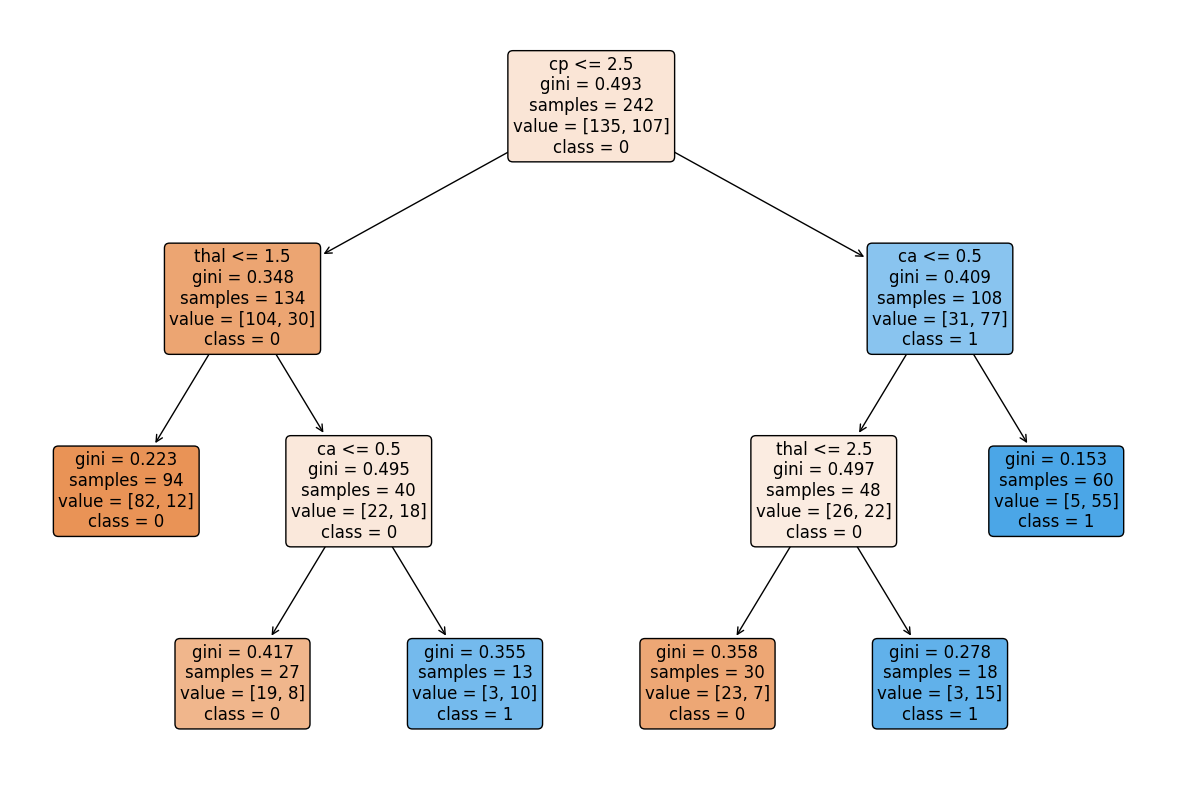

In [ ]:
from sklearn.tree import plot_tree
# Tạo figure và axes
fig, ax = plt.subplots(figsize=(15,10))  # Tạo kích thước cho cây

# Vẽ cây quyết định trên axes
plot_tree(classifier, filled=True, feature_names=df.columns[:-1], class_names=['0', '1'], rounded=True, fontsize=12, ax=ax)

# Hiển thị cây quyết định
plt.show()

Dễ bị overfitting

Confusion Matrix for Train Set:
[[125  10]
 [ 10  97]]
Confusion Matrix for Test Set:
[[26  3]
 [ 3 29]]
Accuracy for Train Set: 0.92
Accuracy for Test Set: 0.9


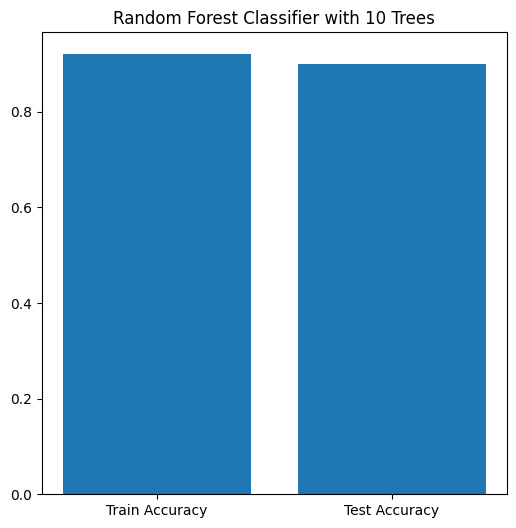

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Tạo mô hình Random Forest với 10 cây quyết định
classifier = RandomForestClassifier(
    n_estimators=10,            # Số lượng cây quyết định trong rừng
    criterion='gini',           # Sử dụng Gini impurity
    max_depth=10,               # Giới hạn độ sâu tối đa của cây
    min_samples_split=20,       # Số lượng mẫu tối thiểu để chia một nút
    random_state=42             # Đảm bảo tính tái lặp
)

# Huấn luyện mô hình
classifier.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = classifier.predict(X_test)

# Tính ma trận nhầm lẫn cho tập kiểm tra
cm_test = confusion_matrix(y_test, y_pred)

# Dự đoán trên tập huấn luyện
y_pred_train = classifier.predict(X_train)

# Tính ma trận nhầm lẫn cho tập huấn luyện
cm_train = confusion_matrix(y_train, y_pred_train)

# In ma trận nhầm lẫn
print("Confusion Matrix for Train Set:")
print(cm_train)

print("Confusion Matrix for Test Set:")
print(cm_test)

# Tính độ chính xác trên tập huấn luyện
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)

# Tính độ chính xác trên tập kiểm tra
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)

# In kết quả độ chính xác
print(f"Accuracy for Train Set: {accuracy_for_train}")
print(f"Accuracy for Test Set: {accuracy_for_test}")

# Vẽ đồ thị nếu cần thiết
plt.figure(figsize=(6,6))
plt.title("Random Forest Classifier with 10 Trees")
plt.bar(['Train Accuracy', 'Test Accuracy'], [accuracy_for_train, accuracy_for_test])
plt.show()


Confusion Matrix for Train Set:
[[134   1]
 [  4 103]]
Confusion Matrix for Test Set:
[[26  3]
 [ 5 27]]
Accuracy for Train Set: 0.98
Accuracy for Test Set: 0.87


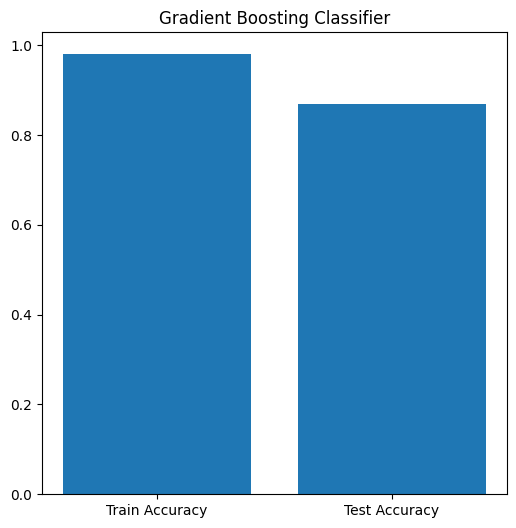

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Tạo mô hình Gradient Boosting với tham số được yêu cầu
classifier = GradientBoostingClassifier(
    learning_rate=0.1,        # Tốc độ học
    n_estimators=70,         # Số lượng cây
    subsample=0.7,            # Sử dụng toàn bộ dữ liệu
    min_samples_split=20,      # Số lượng mẫu tối thiểu để chia một node
    max_depth=3,              # Độ sâu tối đa của cây con
    random_state=42           # Đảm bảo tính tái lặp
)

# Huấn luyện mô hình
classifier.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = classifier.predict(X_test)

# Tính ma trận nhầm lẫn cho tập kiểm tra
cm_test = confusion_matrix(y_test, y_pred)

# Dự đoán trên tập huấn luyện
y_pred_train = classifier.predict(X_train)

# Tính ma trận nhầm lẫn cho tập huấn luyện
cm_train = confusion_matrix(y_train, y_pred_train)

# In ma trận nhầm lẫn
print("Confusion Matrix for Train Set:")
print(cm_train)

print("Confusion Matrix for Test Set:")
print(cm_test)

# Tính độ chính xác trên tập huấn luyện
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)

# Tính độ chính xác trên tập kiểm tra
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)

# In kết quả độ chính xác
print(f"Accuracy for Train Set: {accuracy_for_train}")
print(f"Accuracy for Test Set: {accuracy_for_test}")

# Vẽ biểu đồ so sánh độ chính xác
plt.figure(figsize=(6,6))
plt.title("Gradient Boosting Classifier")
plt.bar(['Train Accuracy', 'Test Accuracy'], [accuracy_for_train, accuracy_for_test])
plt.show()


Confusion Matrix for Train Set:
[[125  10]
 [ 15  92]]
Confusion Matrix for Test Set:
[[26  3]
 [ 6 26]]
Accuracy for Train Set: 0.9
Accuracy for Test Set: 0.85


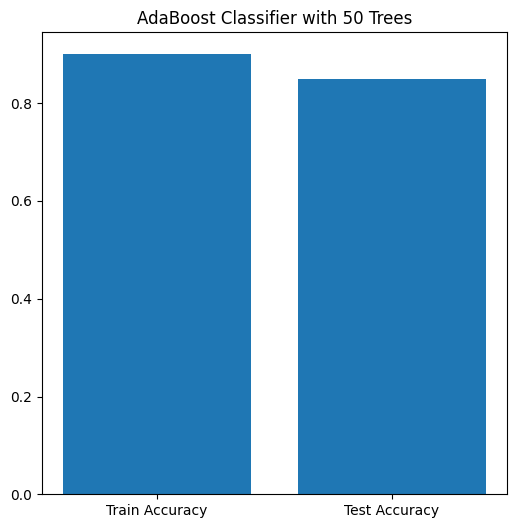

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
# Tạo mô hình AdaBoost với 50 cây quyết định
classifier = AdaBoostClassifier(
    n_estimators=50,             # Số lượng cây quyết định
    learning_rate=0.5,           # Learning rate
    random_state=42              # Đảm bảo tính tái lặp
)

# Huấn luyện mô hình
classifier.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = classifier.predict(X_test)

# Tính ma trận nhầm lẫn cho tập kiểm tra
cm_test = confusion_matrix(y_test, y_pred)

# Dự đoán trên tập huấn luyện
y_pred_train = classifier.predict(X_train)

# Tính ma trận nhầm lẫn cho tập huấn luyện
cm_train = confusion_matrix(y_train, y_pred_train)

# In ma trận nhầm lẫn
print("Confusion Matrix for Train Set:")
print(cm_train)

print("Confusion Matrix for Test Set:")
print(cm_test)

# Tính độ chính xác trên tập huấn luyện
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train), 2)

# Tính độ chính xác trên tập kiểm tra
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)

# In kết quả độ chính xác
print(f"Accuracy for Train Set: {accuracy_for_train}")
print(f"Accuracy for Test Set: {accuracy_for_test}")

# Vẽ đồ thị nếu cần thiết
plt.figure(figsize=(6,6))
plt.title("AdaBoost Classifier with 50 Trees")
plt.bar(['Train Accuracy', 'Test Accuracy'], [accuracy_for_train, accuracy_for_test])
plt.show()


Confusion Matrix for Train Set:
[[132   3]
 [  4 103]]
Confusion Matrix for Test Set:
[[26  3]
 [ 4 28]]
Accuracy for Train Set: 0.97
Accuracy for Test Set: 0.89


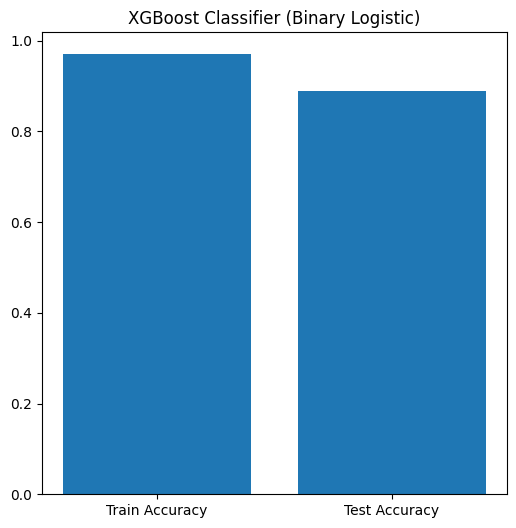

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
classifier = xgb.XGBClassifier(
    n_estimators=100,         # Số lượng cây
    learning_rate=0.1,        # Tốc độ học
    subsample=1.0,            # Sử dụng toàn bộ dữ liệu
    min_child_weight=2,       # Số lượng mẫu tối thiểu để chia một node (tham số thay thế cho min_samples_split)
    max_depth=3,              # Độ sâu tối đa của cây con
    random_state=42,          # Đảm bảo tính tái lặp
    objective='binary:logistic'  # Phân loại nhị phân với hàm logistic
)

# Huấn luyện mô hình
classifier.fit(X_train, y_train_encoded)

# Dự đoán trên tập kiểm tra
y_pred = classifier.predict(X_test)

# Tính ma trận nhầm lẫn cho tập kiểm tra
cm_test = confusion_matrix(y_test_encoded, y_pred)

# Dự đoán trên tập huấn luyện
y_pred_train = classifier.predict(X_train)

# Tính ma trận nhầm lẫn cho tập huấn luyện
cm_train = confusion_matrix(y_train_encoded, y_pred_train)

# In ma trận nhầm lẫn
print("Confusion Matrix for Train Set:")
print(cm_train)

print("Confusion Matrix for Test Set:")
print(cm_test)

# Tính độ chính xác trên tập huấn luyện
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1]) / len(y_train_encoded), 2)

# Tính độ chính xác trên tập kiểm tra
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test_encoded), 2)

# In kết quả độ chính xác
print(f"Accuracy for Train Set: {accuracy_for_train}")
print(f"Accuracy for Test Set: {accuracy_for_test}")

# Vẽ biểu đồ so sánh độ chính xác
plt.figure(figsize=(6,6))
plt.title("XGBoost Classifier (Binary Logistic)")
plt.bar(['Train Accuracy', 'Test Accuracy'], [accuracy_for_train, accuracy_for_test])
plt.show()


Confusion Matrix for Train Set:
[[119  16]
 [ 26  81]]
Confusion Matrix for Test Set:
[[24  5]
 [ 6 26]]
Accuracy for Train Set: 0.83
Accuracy for Test Set: 0.82


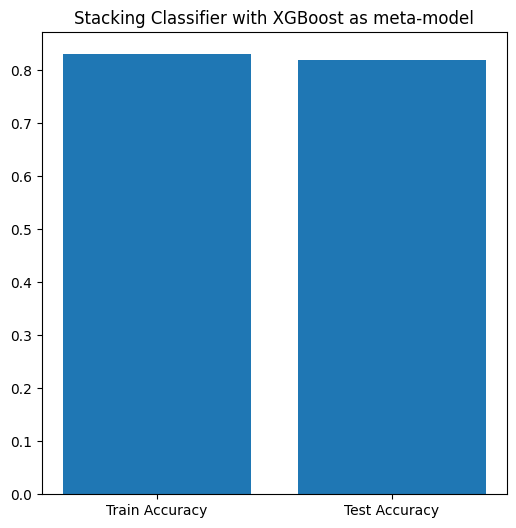

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Các mô hình cơ sở
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
svm = SVC(kernel='linear', random_state=42)
ada = AdaBoostClassifier(n_estimators=100, random_state=42)

# Mô hình meta (mô hình cuối)
meta_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Xây dựng StackingClassifier với các mô hình cơ sở và mô hình meta
stacking_model = StackingClassifier(
    estimators=[('dt', dt), ('rf', rf), ('knn', knn), ('gb', gb), ('svm', svm), ('ada', ada)],
    final_estimator=meta_model
)

# Huấn luyện mô hình stacking
stacking_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_stack = stacking_model.predict(X_test)

# Tính ma trận nhầm lẫn cho tập kiểm tra
cm_test = confusion_matrix(y_test, y_pred_stack)

# Dự đoán trên tập huấn luyện
y_pred_train_stack = stacking_model.predict(X_train)

# Tính ma trận nhầm lẫn cho tập huấn luyện
cm_train_stack = confusion_matrix(y_train, y_pred_train_stack)

# In ma trận nhầm lẫn
print("Confusion Matrix for Train Set:")
print(cm_train_stack)

print("Confusion Matrix for Test Set:")
print(cm_test)

# Tính độ chính xác trên tập huấn luyện
accuracy_for_train = np.round((cm_train_stack[0][0] + cm_train_stack[1][1]) / len(y_train), 2)

# Tính độ chính xác trên tập kiểm tra
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1]) / len(y_test), 2)

# In kết quả độ chính xác
print(f"Accuracy for Train Set: {accuracy_for_train}")
print(f"Accuracy for Test Set: {accuracy_for_test}")

# Vẽ biểu đồ so sánh độ chính xác
plt.figure(figsize=(6,6))
plt.title("Stacking Classifier with XGBoost as meta-model")
plt.bar(['Train Accuracy', 'Test Accuracy'], [accuracy_for_train, accuracy_for_test])
plt.show()


Feature Importances: [0.         0.02288528 0.         0.         0.         0.
 0.         0.70583856 0.         0.         0.         0.
 0.         0.01356259 0.00200417 0.         0.00715165 0.01716396
 0.         0.         0.07018674 0.11406234 0.         0.0366527
 0.01049202 0.         0.         0.         0.         0.        ]


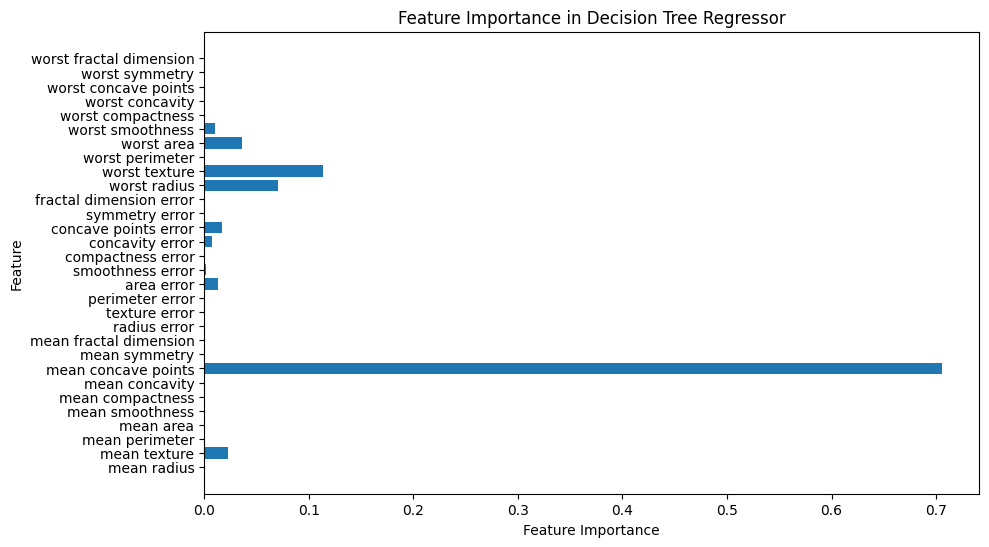

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# Tải bộ dữ liệu breast cancer
data = load_breast_cancer()
X = data.data  # Các đặc trưng
y = data.target  # Nhãn (0 hoặc 1)

# Chia bộ dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Khởi tạo Decision Tree Regressor (hồi quy)
model = DecisionTreeRegressor(random_state=42)

# Huấn luyện mô hình
model.fit(X_train, y_train)

# Lấy độ quan trọng của các đặc trưng
feature_importances = model.feature_importances_

# In độ quan trọng của các đặc trưng
print("Feature Importances:", feature_importances)

# Vẽ đồ thị độ quan trọng của các đặc trưng
plt.figure(figsize=(10, 6))
plt.barh(data.feature_names, feature_importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Decision Tree Regressor")
plt.show()
